# Drought Data

A time series regression problem with historical Drought Severity and Coverage Index data, from the U.S. Drought Monitor.

## 1. Preamble

### Basic

In [1]:
import os
import sys
import time

import numpy as np

from math import pi

# import inspect
import multiprocessing as mp
import warnings

### Data Handling and Cleaning

In [2]:
import pandas as pd
import datetime as dt

from sklearn import set_config

Ensuring all Pipelines output `pandas.DataFrame`, globally!

In [3]:
set_config(transform_output="pandas") # globally!

pd.set_option('display.max_columns', None) # displaying all columns!

### Data Visualization and Analysis

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [5]:
# very pretty plots!
plt.style.use('fivethirtyeight')

# Override aggressive elements
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

Defining the colors and the palette:

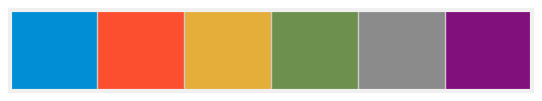

In [6]:
colors_538 = plt.rcParams['axes.prop_cycle'].by_key()['color']
palette_538 = sns.color_palette()

sns.palplot(palette_538)

Putting the the `matplotlib` verbosity at the `warning` level or above (_i.e._, `error` and `critical`):

In [7]:
plt.set_loglevel('WARNING')

### Memory Handling

The "safe" number of CPUs we can use:

In [8]:
import multiprocessing as mp

# number of cores in laptop, minus 2 (so we free one *physical* core)
reserve_cpus = 4
safe_cpus = mp.cpu_count() - reserve_cpus
print(safe_cpus)

16


Functions that find memory size of an object, and all references to it:

In [9]:
def get_object_size(obj):
    """
    Return the memory footprint of an object in bytes.

    If the object is a pandas DataFrame or Series, attempt to compute its
    deep memory usage; otherwise, fall back to using sys.getsizeof.

    Args:
        obj: The object whose memory size will be computed.

    Returns:
        int: The size of the object in bytes.
    """

    if isinstance(obj, pd.DataFrame) or isinstance(obj, pd.Series):
        try:
            return obj.memory_usage(deep=True).sum()
        except:
            return sys.getsizeof(obj)
    return sys.getsizeof(obj)

def find_named_references(obj, namespace=None):
    """
    Find variable names in a given namespace that reference a specific object.

    Args:
        obj: The object to search for.
        namespace (dict, optional): A mapping of variable names to objects.
            Defaults to the global namespace.

    Returns:
        list[str]: Names of variables that reference the given object.
    """

    if namespace is None:
        namespace = globals()
    return [name for name, val in namespace.items() if val is obj]

Examples of use:

In [10]:
# all_sizes = {}
# for name in dir():
#     all_sizes[name] = get_object_size(globals()[name])

# del name

In [11]:
# sorted(all_sizes, key=lambda k: all_sizes[k], reverse=True)

In [12]:
# sum(list(all_sizes.values()))/1024/1024

# del all_sizes

### Cleanup

In [13]:
Out.clear()

for name in dir():
    if name.startswith('_') and name[1:].isdigit():
        del globals()[name]

del name

## 2. Data loading, cleaning, and manipulation

We will prepare the dataset. First, let us look at the data directory:

In [14]:
# defining path to data files
data_path = "../data/"

for filename in os.listdir(data_path):
    print(filename)

dm_export_20000101_20250925.csv


Importing the raw data:

In [15]:
raw_data = pd.read_csv(data_path+"dm_export_20000101_20250925.csv")
display(raw_data)

,Name,MapDate,DSCI
0,CONUS,20000104,84
1,CONUS,20000111,97
2,CONUS,20000118,104
3,CONUS,20000125,105
4,CONUS,20000201,104
...,...,...,...
1338,CONUS,20250826,112
1339,CONUS,20250902,120
1340,CONUS,20250909,124
1341,CONUS,20250916,137


Manipulating the data:

In [16]:
data = raw_data.copy()
data.pop("Name")

data.rename(columns={"MapDate":"date", "DSCI":"dsci"}, inplace=True)
data["date"] = data["date"].map(lambda x:dt.datetime.strptime(str(x), "%Y%m%d"))

data["dsci"] = data["dsci"].astype(float)

display(data)

,date,dsci
0,2000-01-04,84.0
1,2000-01-11,97.0
2,2000-01-18,104.0
3,2000-01-25,105.0
4,2000-02-01,104.0
...,...,...
1338,2025-08-26,112.0
1339,2025-09-02,120.0
1340,2025-09-09,124.0
1341,2025-09-16,137.0


In [17]:
data.describe()

,date,dsci
count,1343,1343.000000
mean,2012-11-13 00:00:00,107.314222
min,2000-01-04 00:00:00,11.000000
25%,2006-06-09 12:00:00,77.000000
50%,2012-11-13 00:00:00,105.000000
75%,2019-04-19 12:00:00,133.500000
max,2025-09-23 00:00:00,215.000000
std,NaN,43.316268


There is no missing data:

In [18]:
data.isna().sum()

date    0
dsci    0
dtype: int64

Checking that all the timestamps are weekly:

In [19]:
time_deltas = (data["date"] - data["date"].shift(1)).map(lambda x: x.days)[1:]

print("All entries with timestamp differences that are not a week's length:\n", time_deltas[(time_deltas != 7)]) # time differences that are not weekly

del time_deltas

All entries with timestamp differences that are not a week's length:
 Series([], Name: date, dtype: float64)


## 3. Exploratory Data Analysis

### 3.1 Loading Modules

In [ ]:
from statsmodels.tsa.deterministic import DeterministicProcess, Fourier
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.linear_model import LinearRegression
from scipy.signal import periodogram, find_peaks

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from scipy.interpolate import interp1d
from sktime.split import SlidingWindowSplitter

### 3.2 Our first view

The number of years of observation:

In [ ]:
(data['date'].iloc[-1] - data['date'].iloc[0]).days / 365.25

25.71937029431896

A lineplot:

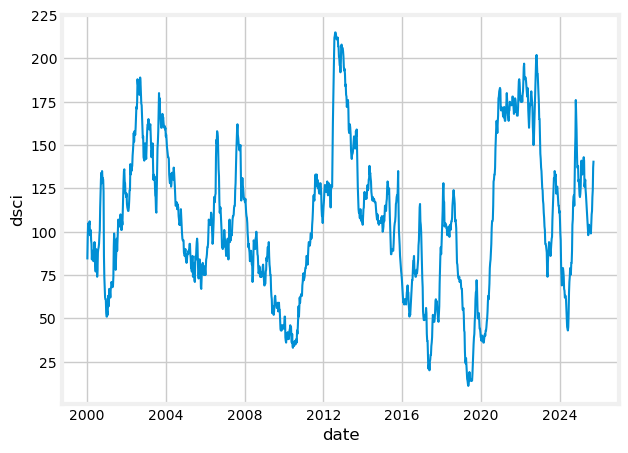

In [ ]:
sns.lineplot(data=data, x='date', y='dsci');

### 3.3 Feature engineering

In this section we dedicate ourselves to engineering some features that may be useful to describe and forecast our time series.

#### Helper functions

Some quick and easy functions to create constant and trend dummies, moving averages, and lags:

In [36]:
def create_dummies(dataset, order=0):
    
    df = dataset.copy()
    
    # Dummies: constant, and trend-like
    dp = DeterministicProcess(index=df.index,
                              constant=True,
                              order=1,
                              drop=True)

    df = pd.concat([df, dp.in_sample()], axis=1)

    if order == 1:
        df.rename(columns={'trend':'dummy'}, inplace=True)
    
    return df



def create_ma(dataset, windows=[26, 52, 52*2, 52*3, 52*4, 52*7, 52*8], to_center=False):
    
    df = dataset.copy()

    # Moving averages
    for w in windows:
        
        if w <= 52:
            name = f"ma{w}"
        else:
            name = f"ma{int(np.round(w/52))}yr"
        
        df[name] = df["dsci"].rolling(window=w,
                                      center=to_center,
                                      min_periods=int(np.round(w//2))).mean()
    
    return df



def create_lags(dataset, lags=[1, 2, 3, 4, 13, 26, 52]):

    df = dataset.copy()

    # Lags
    for lag in lags:
        df[f"lag_{lag}"] = df["dsci"].shift(lag)
    
    return df



def feat_eng(dataset,
             dummyQ=True,
             MAQ=True,
             windows=[26, 52, 52*2, 52*3, 52*4, 52*7, 52*8],
            #  windows=[26, 52, 52*4, 52*8],
             MA_centered=False,
             lagsQ=True,
             lags=[1, 2, 3, 4, 13, 26, 52]):
    
    df = dataset.copy()

    if dummyQ:
        df = create_dummies(df)
    
    if MAQ:
        df = create_ma(df, windows=windows, to_center=MA_centered)
    
    if lagsQ:
        df = create_lags(df, lags=lags)
    
    return df

Creating those engineered features:

In [37]:
data_eda = feat_eng(data)

#### Moving Averages

We begin with line plots of the moving averages:

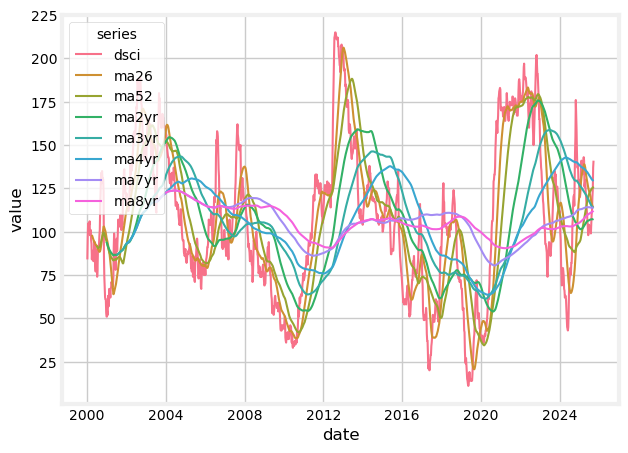

In [38]:
cols = ['dsci'] + [col for col in data_eda.columns if 'ma' in col]

df_long = data_eda.melt(id_vars="date", value_vars=cols,
                        var_name="series", value_name="value")

# Plot
sns.lineplot(data=df_long, x="date", y="value", hue="series")

del cols, df_long

It seems evident that there is a seasonality of ~ 10 years. We will make this clearer once we study the periodogram of the time series and its moving averages in a robust manner, to avoid spurious long-term periods due to the finitude of the observation window (~24 years).

period1: 8.282051282051283
period2: 4.9692307692307685
period1: 8.115384615384615
period2: 4.86923076923077
period1: 7.948717948717948
period2: 4.769230769230769


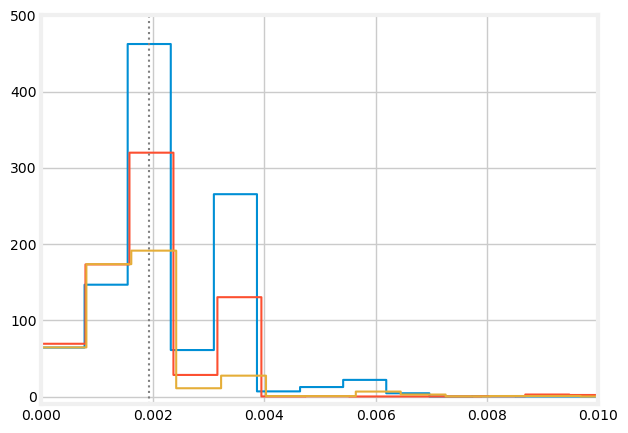

In [42]:
for ma in (2, 3, 4):
    
    name = f"ma{ma}yr"
    ffs, pps = periodogram(data_eda[name][data_eda[name].isna() == False],
                           detrend='constant',
                           scaling='spectrum')

    # plt.plot(ffs, pps)
    plt.step(ffs, pps)

    max1_freq_loc = np.argmax(pps)
    
    print("period1:", 1/ffs[max1_freq_loc] / 52)

    max2_freq_loc = max1_freq_loc + 1 + np.argmax(pps[max1_freq_loc+1:])

    print("period2:", 1/ffs[max2_freq_loc] / 52)

plt.vlines(1./(52*10), ymin=-10, ymax=1000, colors='gray', ls=':')
plt.xlim(0, 0.01)
plt.ylim(-10, 500)

del name, ma, max1_freq_loc, max2_freq_loc

### 3.4 Trend

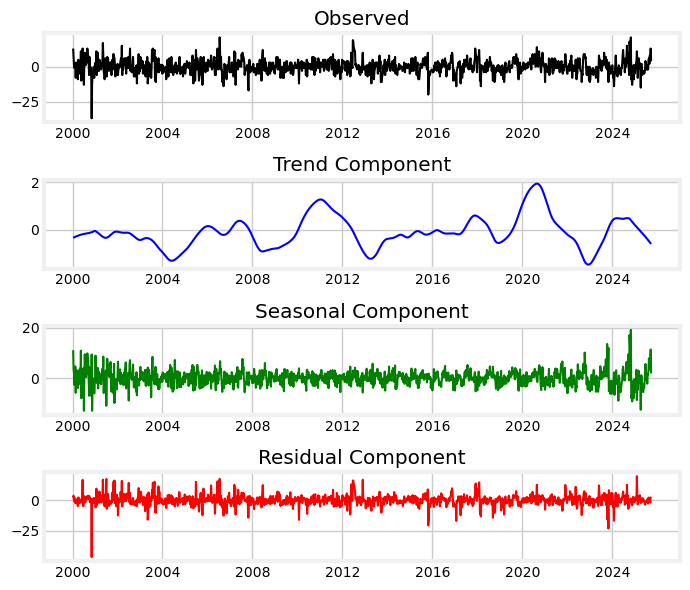

In [131]:
# tmp_data = data['dsci'] - data['dsci'].mean()

tmp_data = (data_eda['dsci'] - data_eda['lag_1']).iloc[1:]
tmp_data -= tmp_data.mean()

start = len(data_eda) - len(tmp_data)

stl = STL(tmp_data,
          # period=447,
          period=52,
          # period = int(np.round(3.2283653846153846 * 52)),
          seasonal=7,
        #   seasonal=52+1,
          robust=True)
result = stl.fit()

# Plot the decomposition components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(7, 6))

ax1.plot(data.date[start:], result.observed, label='Observed', color='black')
ax1.set_title('Observed')

ax2.plot(data.date[start:], result.trend, label='Trend', color='blue')
ax2.set_title('Trend Component')

ax3.plot(data.date[start:], result.seasonal, label='Seasonal', color='green')
ax3.set_title('Seasonal Component')

ax4.plot(data.date[start:], result.resid, label='Residual', color='red')
ax4.set_title('Residual Component')

plt.tight_layout()
plt.show()

del tmp_data, start
del fig, ax1, ax2, ax3, ax4
# del stl, result

In [113]:
from scipy.stats import pearsonr

In [118]:
np.clip(result.observed, a_min=-20, a_max=20)

1       12.957526
2        6.957526
3        0.957526
4       -1.042474
5       -0.042474
          ...    
1338     1.957526
1339     7.957526
1340     3.957526
1341    12.957526
1342     3.957526
Length: 1342, dtype: float64

PearsonRResult(statistic=np.float64(-0.05777897453968173), pvalue=np.float64(0.034308134434322))

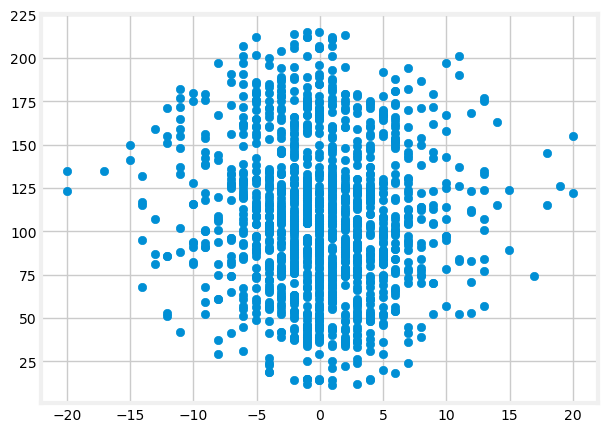

In [120]:
plt.scatter(np.clip(result.observed, a_min=-20, a_max=20), data_eda['lag_1'].iloc[1:])

pearsonr(np.clip(result.observed, a_min=-20, a_max=20), data_eda['lag_1'].iloc[1:])

PearsonRResult(statistic=np.float64(-0.05760184737535184), pvalue=np.float64(0.034864174477989174))

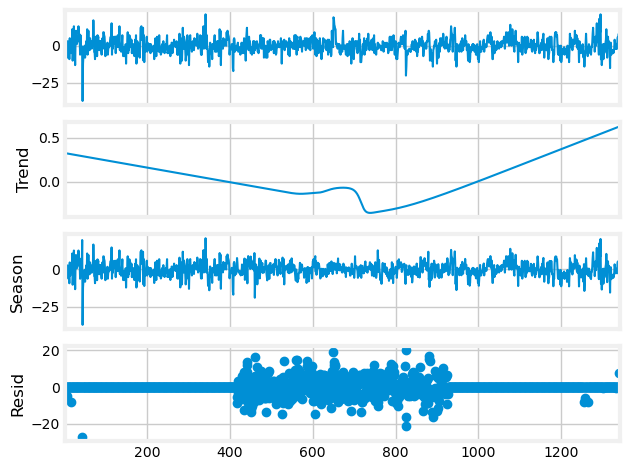

In [90]:
result.plot();

0.03129657228017884
31.95238095238095
0.6144688644688644


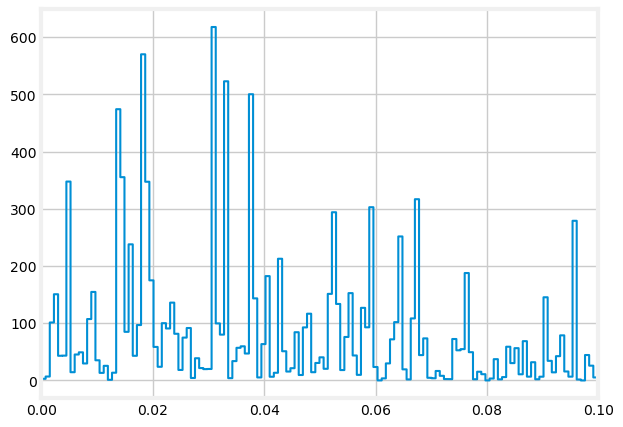

In [124]:
ff, pp = periodogram(result.seasonal)
plt.step(ff, pp)
plt.xlim(0, 0.1)

print(ff[np.argmax(pp)])
print(1/ff[np.argmax(pp)])
print(1/ff[np.argmax(pp)] / 52)

# del ff, pp

In [53]:
(data['dsci'] - data['dsci'].mean()) - result.observed

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1338    0.0
1339    0.0
1340    0.0
1341    0.0
1342    0.0
Name: dsci, Length: 1343, dtype: float64

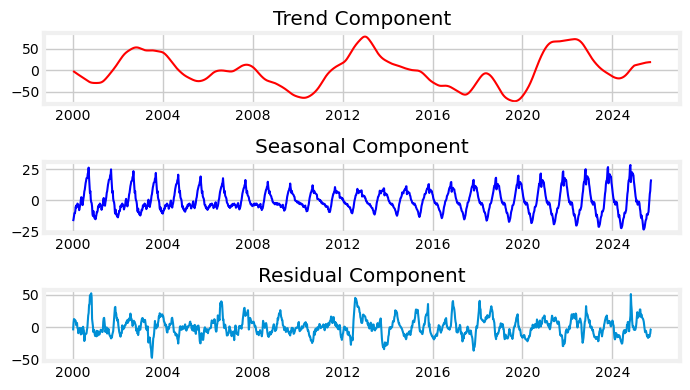

In [32]:
stl = STL(data['dsci'] - data['dsci'].mean(),
          period=52,
          # seasonal=13,
          seasonal=52*3+1,
          robust=True)
result = stl.fit()

# Plot the decomposition components
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 4))

ax1.plot(data.date, result.trend, label='Trend', color='red')
ax1.set_title('Trend Component')
ax2.plot(data.date, result.seasonal, label='Seasonal', color='blue')
ax2.set_title('Seasonal Component')
ax3.plot(data.date, result.resid, label='Residual')
ax3.set_title('Residual Component')
plt.tight_layout()
plt.show()

In [122]:
reg_choice = 'c'

# ADF (Augmented Dickey–Fuller) test
adf_result = adfuller(data['dsci'], regression=reg_choice, autolag='AIC')
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\n")

# KPSS (Kwiatkowski–Phillips–Schmidt–Shin) test
kpss_result = kpss(data['dsci'], regression=reg_choice)  # 'c' = constant
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

print("\n")

if (adf_result[1] < 0.05) and (kpss_result[1] >= 0.05):
    print("Strong evidence of stationarity!")

elif (adf_result[1] >= 0.05) and (kpss_result[1] < 0.05):
    print("Strong evidence of non-stationarity!")

elif (adf_result[1] >= 0.05) and (kpss_result[1] >= 0.05):
    print("Inconclusive, series may be trend-stationary")

else:
    print("Possible structural breaks or near-unit-root behavior")

print("\n")

ADF Statistic: -3.335517562257653
p-value: 0.013363589684003153


KPSS Statistic: 0.1704333002545023
p-value: 0.1


Strong evidence of stationarity!




/tmp/ipykernel_17967/188057163.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(data['dsci'], regression=reg_choice)  # 'c' = constant


Fitting a linear regression model to find the trend.

In [34]:
def create_trend(dataset, verbose=True):

    df = dataset.copy()

    X, y = df[['const', 'dummy']], df['dsci']

    trend_model = LinearRegression(fit_intercept=False)
    trend_model.fit(X[:1000], y[:1000])

    if verbose:
        print(f"intercept={trend_model.intercept_}\ncoefficients={trend_model.coef_}")
    
    df['trend'] = trend_model.predict(X)
    df['de-trend'] = df['dsci'] - df['trend']

    return df

In [35]:
data_eda = feat_eng(data)
data_eda = create_trend(data_eda)

KeyError: "['dummy'] not in index"

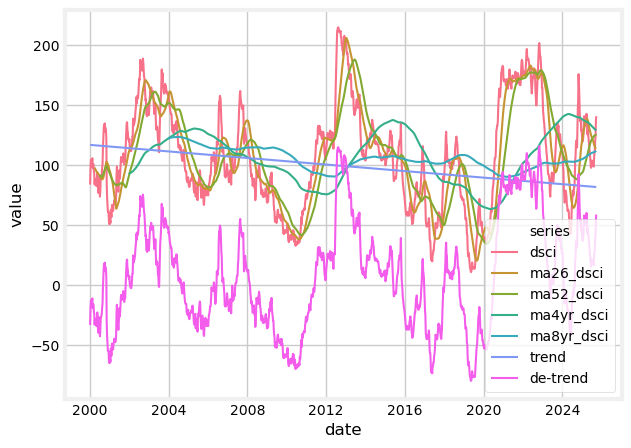

In [ ]:
cols = ['dsci'] + [col for col in data_eda.columns if 'ma' in col] + ['trend', 'de-trend']

df_long = data_eda.melt(id_vars="date", value_vars=cols,
                        var_name="series", value_name="value")

# Plot
sns.lineplot(data=df_long, x="date", y="value", hue="series")

del cols, df_long

### 3.5 Periodogram, Fourier series, and seasonality

Let us now compute the periodogram of the de-trended time series:

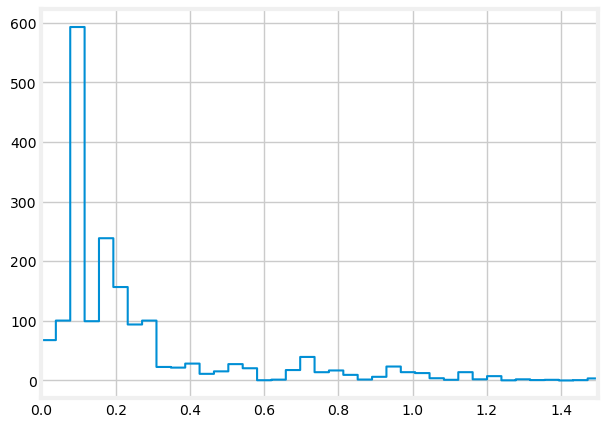

In [ ]:
frac = 100/100 # 100%
# ini, end = 0, None # the whole data!
ini, end = 0, int(len(data)*frac) # first fraction
# ini, end = int(len(data)*(1-frac)), None # last fraction
if frac == 1:
    end = None

freq_arr, pxx_arr = periodogram(data_eda['de-trend'].iloc[ini:end],
                                fs=1, # frequencies in units of 1/week
                                # fs=52, # so we have frequencies in units of 1/year
                                detrend=,
                                scaling='spectrum')

plt.step(freq_arr*52, pxx_arr)
plt.xlim(0, 1.5);

del freq_arr, pxx_arr

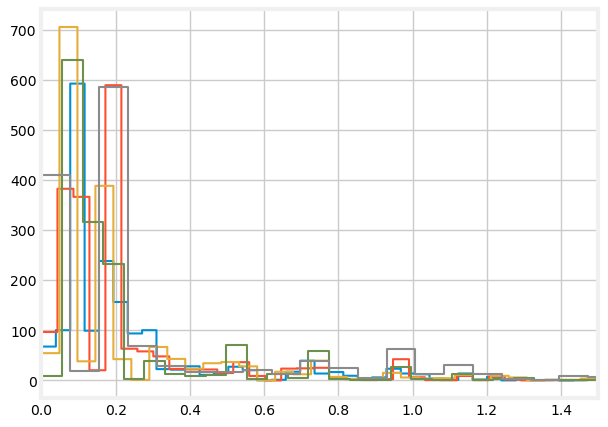

In [ ]:
first_or_last = 'first'

for frac in [1, 0.9, 0.8, 0.7, 0.5]:
    
    if first_or_last == 'first':
        ini, end = 0, int(len(data)*frac) # first fraction
    elif first_or_last == 'last':
        ini, end = int(len(data)*(1-frac)), None # last fraction
    else:
        continue
    
    if frac == 1:
        end = None
    
    freq_arr, pxx_arr = periodogram(data_eda['de-trended'].iloc[ini:end],
                                fs=1, # frequencies in units of 1/week
                                # fs=52, # so we have frequencies in units of 1/year
                                detrend='constant',
                                scaling='spectrum')
    
    plt.step(freq_arr*52, pxx_arr)

# plt.xlim(0, 3.);
plt.xlim(0, 1.5);
# plt.xlim(0, 5.);

del first_or_last, frac, ini, end, freq_arr, pxx_arr

In [ ]:
def robust_periodogram(dataset, col_name='de-trended', frac=0.5, fh=26, sl=10):

    wl = (int(frac*len(data)))

    df = dataset.copy()

    spec = []

    splitter = SlidingWindowSplitter(window_length=wl, fh=fh, step_length=sl)

    for train_idx, _ in splitter.split(df):

        # print(train_idx)

        ffs, pps = periodogram(df.loc[train_idx,col_name],
                               fs=1, # frequencies in units of 1/week
                               detrend='constant',
                               scaling='spectrum')
        
        spec.append(pps)
    
    spec = np.array(spec).T
    
    spectrum = np.mean(spec, axis=1)
    
    return ffs, spectrum, spec

In [ ]:
freq_arr = np.linspace(0, 0.5, 400)

pp_fracs = []

for i, frac in enumerate(np.linspace(0.6, 0.9, 11)):

    ffs, pxx, _ = robust_periodogram(data_eda, frac=frac)

    if i == 0:
        print(len(ffs))

    pp_fn = interp1d(ffs, pxx, bounds_error=False, fill_value='extrapolate')

    pp_fracs.append(pp_fn(freq_arr))

pp_fracs = np.array(pp_fracs).T
pp_fracs = pp_fracs.mean(axis=1)

403


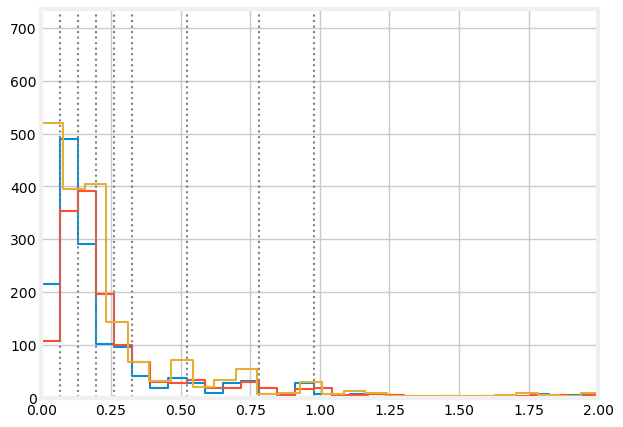

In [ ]:
ffs, pxx, _ = robust_periodogram(data_eda, frac=0.5)
clipped_pxx = np.clip(pxx, a_min=30, a_max=None)

clipped_pp = np.clip(pp_fracs, a_min=20, a_max=None)

pp_df = pd.DataFrame(np.vstack([freq_arr, pp_fracs]).T)
ma_pp = pp_df[1].rolling(window=2,
                         center=True,
                         min_periods=1).mean().to_numpy()
clipped_ma_pp = np.clip(ma_pp, a_min=30, a_max=None)

tmp_periods1 = (1/(52*freq_arr[find_peaks(clipped_pp)[0]]))[1/(52*freq_arr[find_peaks(clipped_pp)[0]]) > 0.25]
tmp_freqs1 = (1/tmp_periods1)/52
tmp_freqs1 = np.append(tmp_freqs1, freq_arr[pp_fracs > 90])
tmp_freqs1 = np.sort(np.unique(tmp_freqs1))

tmp_periods2 = (1/(52*ffs[find_peaks(clipped_pxx)[0]]))[1/(52*ffs[find_peaks(clipped_pxx)[0]]) > 0.25]
tmp_freqs2 = (1/tmp_periods2)/52

plt.step(freq_arr*52, pp_fracs)
plt.step(freq_arr*52, ma_pp)
plt.step(ffs*52, pxx)

plt.vlines(tmp_freqs1*52, ymin=-10, ymax=1_000, colors='grey', ls=':')
# plt.vlines(tmp_freqs2*52, ymin=-10, ymax=1_000, colors='grey', ls=':')
plt.xlim(0, 2);
plt.ylim(-1, np.nanmax([pp_fracs, ma_pp])*1.5);

# del ffs, pxx, tmp_periods1, tmp_freqs1, tmp_periods2, tmp_freqs2

In [ ]:
tmp_periods1

array([7.67307692, 1.91826923, 1.27884615, 1.02307692])

In [ ]:
365.25/7

52.17857142857143

From here we can compute the Fourier components; we focus on the first two harmonics of the most important frequency:

In [ ]:
def fourier_features(ts, freqs, order, time_col='dummy'):

    tarr = ts[time_col].to_numpy()

    ff_cols = {}
    for freq in freqs:
        for n in range(1, order+1):

            sin_col = f'sin_{n}*{freq:.3}'
            cos_col = f'cos_{n}*{freq:.3}'

            ff_cols[sin_col] = np.sin(2*pi*n*freq*tarr)
            ff_cols[cos_col] = np.cos(2*pi*n*freq*tarr)
    
    ff_df = pd.DataFrame(ff_cols, index=ts.index)

    return ff_df

In [ ]:
data_eda = feat_eng(data)
data_eda = create_trend(data_eda, verbose=False)

# freqs = [1/(weeks_in_year*10),
#          1/(weeks_in_year*8),
#          1/(weeks_in_year*5),
#          1/(weeks_in_year*4),
#          1/(weeks_in_year*3),
#          1/(weeks_in_year*2),
#          1/weeks_in_year,
#          1/(weeks_in_year/2),
#          1/(weeks_in_year/4)]
# freqs = (1/((1/(52*ffs[find_peaks(pxx)[0]]))[1/(52*ffs[find_peaks(pxx)[0]]) > 0.25]))/52
# freqs = tmp_freqs1

for fund_yr_freq in [10, 8]:

    if fund_yr_freq == 10:
        max_harmonic = 3
    else:
        max_harmonic = 32

    freqs = [1/(52*fund_yr_freq)]
    
    data_eda = pd.concat([data_eda, fourier_features(data_eda, freqs, max_harmonic)], axis=1)

display(data_eda)

# del freqs

,date,dsci,dummy,ma26_dsci,ma52_dsci,ma4yr_dsci,ma8yr_dsci,lag_1,lag_2,lag_3,lag_4,lag_13,lag_26,lag_52,trend,de-trended,sin_1*0.00192,cos_1*0.00192,sin_2*0.00192,cos_2*0.00192,sin_3*0.00192,cos_3*0.00192,sin_1*0.0024,cos_1*0.0024,sin_2*0.0024,cos_2*0.0024,sin_3*0.0024,cos_3*0.0024,sin_4*0.0024,cos_4*0.0024,sin_5*0.0024,cos_5*0.0024,sin_6*0.0024,cos_6*0.0024,sin_7*0.0024,cos_7*0.0024,sin_8*0.0024,cos_8*0.0024,sin_9*0.0024,cos_9*0.0024,sin_10*0.0024,cos_10*0.0024,sin_11*0.0024,cos_11*0.0024,sin_12*0.0024,cos_12*0.0024,sin_13*0.0024,cos_13*0.0024,sin_14*0.0024,cos_14*0.0024,sin_15*0.0024,cos_15*0.0024,sin_16*0.0024,cos_16*0.0024,sin_17*0.0024,cos_17*0.0024,sin_18*0.0024,cos_18*0.0024,sin_19*0.0024,cos_19*0.0024,sin_20*0.0024,cos_20*0.0024,sin_21*0.0024,cos_21*0.0024,sin_22*0.0024,cos_22*0.0024,sin_23*0.0024,cos_23*0.0024,sin_24*0.0024,cos_24*0.0024,sin_25*0.0024,cos_25*0.0024,sin_26*0.0024,cos_26*0.0024,sin_27*0.0024,cos_27*0.0024,sin_28*0.0024,cos_28*0.0024,sin_29*0.0024,cos_29*0.0024,sin_30*0.0024,cos_30*0.0024,sin_31*0.0024,cos_31*0.0024,sin_32*0.0024,cos_32*0.0024
0,2000-01-04,84.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105.707099,-21.707099,0.012083,0.999927,0.024164,0.999708,0.036241,0.999343,0.015103,0.999886,0.030203,0.999544,0.045296,0.998974,0.060378,0.998176,0.075447,0.997150,0.090499,0.995897,0.105530,0.994416,0.120537,9.927089e-01,0.135516,0.990775,0.150465,0.988615,0.165379,0.986230,0.180255,0.983620,0.195090,0.980785,0.209881,0.977727,0.224624,0.974446,2.393157e-01,0.970942,0.253953,0.967217,0.268532,0.963271,0.283050,0.959105,0.297503,0.954721,0.311888,0.950119,0.326203,0.945300,0.340443,0.940265,0.354605,9.350162e-01,0.368686,0.929554,0.382683,9.238795e-01,0.396593,0.917994,0.410413,0.911900,0.424139,0.905597,0.437768,0.899088,0.451297,0.892374,4.647232e-01,0.885456
1,2000-01-11,97.0,2.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,NaN,NaN,105.709494,-8.709494,0.024164,0.999708,0.048313,0.998832,0.072435,0.997373,0.030203,0.999544,0.060378,0.998176,0.090499,0.995897,0.120537,0.992709,0.150465,0.988615,0.180255,0.983620,0.209881,0.977727,0.239316,9.709418e-01,0.268532,0.963271,0.297503,0.954721,0.326203,0.945300,0.354605,0.935016,0.382683,0.923880,0.410413,0.911900,0.437768,0.899088,4.647232e-01,0.885456,0.491255,0.871016,0.517338,0.855781,0.542949,0.839766,0.568065,0.822984,0.592662,0.805451,0.616719,0.787183,0.640213,0.768198,0.663123,7.485107e-01,0.685427,0.728141,0.707107,7.071068e-01,0.728141,0.685427,0.748511,0.663123,0.768198,0.640213,0.787183,0.616719,0.805451,0.592662,8.229839e-01,0.568065
2,2000-01-18,104.0,3.0,NaN,NaN,NaN,NaN,97.0,84.0,NaN,NaN,NaN,NaN,NaN,105.711889,-1.711889,0.036241,0.999343,0.072435,0.997373,0.108533,0.994093,0.045296,0.998974,0.090499,0.995897,0.135516,0.990775,0.180255,0.983620,0.224624,0.974446,0.268532,0.963271,0.311888,0.950119,0.354605,9.350162e-01,0.396593,0.917994,0.437768,0.899088,0.478043,0.878336,0.517338,0.855781,0.555570,0.831470,0.592662,0.805451,0.628538,0.777779,6.631227e-01,0.748511,0.696347,0.717706,0.728141,0.685427,0.758441,0.651742,0.787183,0.616719,0.814310,0.580430,0.839766,0.542949,0.863497,0.504354,0.885456,4.647232e-01,0.905597,0.424139,0.923880,3.826834e-01,0.940265,0.340443,0.954721,0.297503,0.967217,0.253953,0.977727,0.209881,0.986230,0.165379,9.927089e-01,0.120537
3,2000-01-25,105.0,4.0,NaN,NaN,NaN,NaN,104.0,97.0,84.0,NaN,NaN,NaN,NaN,105.714284,-0.714284,0.048313,0.998832,0.096514,0.995332,0.144489,0.989506,0.060378,0.998176,0.120537,0.992709,0.180255,0.983620,0.239316,0.970942,0.297503,0.954721,0.354605,0.935016,0.410413,0.911900,0.464723,8.854560e-01,0.517338,0.855781,0.568065,0.822984,0.616719,0.787183,0.663123,0.748511,0.707107,0.707107,0.748511,0.663123,0.787183,0.616719,8.229839e-01,0.568065,0.855781,0.517338,0.885456,0.464723,0.911900,0.410413,0.935016,0.354605,0.954721,0.297503,0.970942,0.239316,0.983620,0.180255,0.992709,1.205367e-01,0.998176,0.060378,1.000000,-1.608123e-16,0.998176,-0.060378,0.992709,-0.120537,0.983620,-0.180255,0.970942,-0.2

In [ ]:
fourier_cols = [col for col in data_eda.columns if ('sin_' in col) or ('cos_' in col)]

season_model = LinearRegression(fit_intercept=False)
season_model.fit(data_eda[fourier_cols], (data_eda['dsci'] - data_eda['trend']))
print(f"intercept={season_model.intercept_}\ncoefficients={season_model.coef_}")

intercept=0.0
coefficients=[ 2.66404371e+01 -9.80552482e+00 -6.27370597e+00 -2.42137708e+01
 -6.48069209e+00 -7.64445059e+00 -1.83504441e+01  1.96301957e-01
  4.30497858e+00 -1.14436046e+00 -2.78431011e+00  4.09333287e+00
  3.99890841e+00 -5.96460823e+00  9.54312041e-01  2.19913040e+00
 -7.44912850e+00  5.53300252e+00 -4.39364889e-01  3.26106612e-01
 -6.34638277e+00  4.02825590e+00  9.72989686e-01  6.79962933e-01
 -1.81421150e+00  4.16925234e+00 -1.64898854e-01 -1.94263284e-01
 -1.46844114e+00 -2.45811321e-02  1.41926464e+00  9.33858683e-05
 -8.94891502e-01 -6.65192037e-01 -3.27646760e-01 -1.87691123e-01
  1.13460419e+00 -3.60321793e+00 -1.90409866e+00  4.81222423e-01
 -4.85117671e-01  1.88697556e-01  4.09319232e-01 -4.18582170e-01
  3.50632177e-01 -1.50430055e+00  1.16949738e+00 -8.35434261e-01
  9.35158349e-03 -4.59080099e-01  5.27262118e-01  8.01005043e-01
  2.28831508e-01  1.68474645e+00 -7.87778757e-01  4.44404701e-02
  1.16907183e-01 -2.76447732e-02  1.17045971e+00 -5.69094799e-0

In [ ]:
fourier_fns = season_model.coef_ * data_eda[fourier_cols]

# sns.lineplot(fourier_fns)

# del fourier_fns

In [ ]:
fourier_fns.sum(axis=1)

0      -34.783810
1      -35.007194
2      -35.295231
3      -35.884200
4      -36.948054
          ...    
1338   -32.052748
1339   -31.884970
1340   -32.133362
1341   -32.902287
1342   -34.236502
Length: 1343, dtype: float64

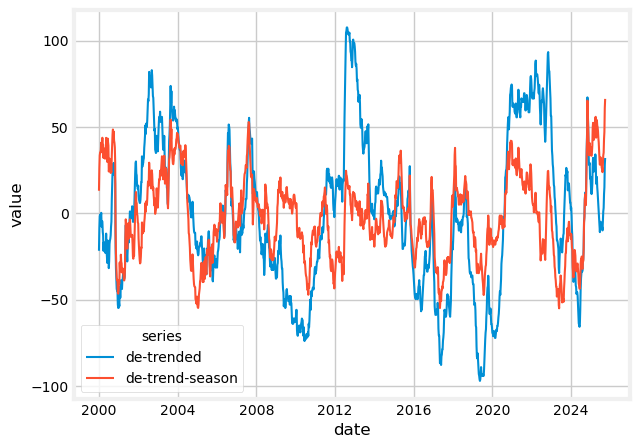

In [ ]:
de_trend_season = data_eda['dsci'] - data_eda['trend'] - (fourier_fns.sum(axis=1))
data_eda['de-trend-season'] = de_trend_season

cols = ['de-trended', 'de-trend-season']

df_long = data_eda.melt(id_vars="date", value_vars=cols,
                        var_name="series", value_name="value")

sns.lineplot(df_long, x="date", y="value", hue="series")

del df_long

In [ ]:
np.std(de_trend_season)

24.146543022245407

(array([ 32., 102., 152., 233., 243., 237., 107., 135.,  72.,  30.]),
 array([-97.12616625, -76.64161866, -56.15707106, -35.67252346,
        -15.18797586,   5.29657174,  25.78111934,  46.26566694,
         66.75021454,  87.23476214, 107.71930973]),
 <BarContainer object of 10 artists>)

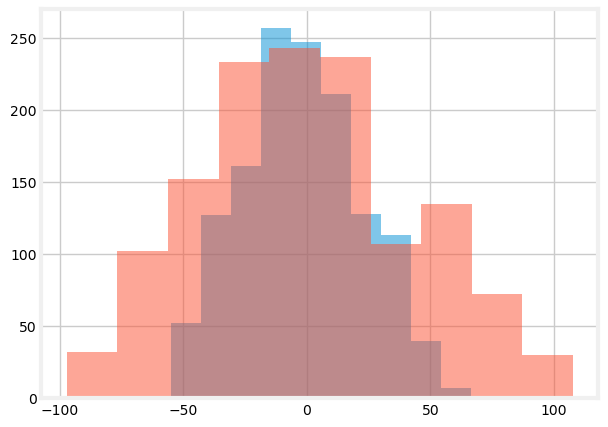

In [ ]:
plt.hist(de_trend_season, alpha=0.5)
plt.hist(data_eda['de-trended'], alpha=0.5)

In [ ]:
1/freqs2[np.argmax(pxx2)] / 52

np.float64(3.689560439560439)

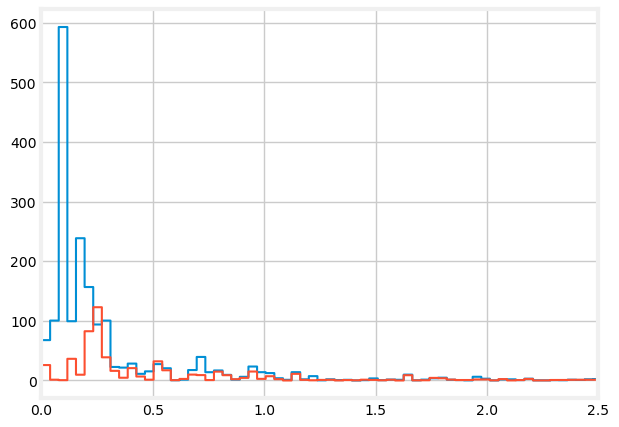

In [ ]:
freqs1, pxx1 = periodogram(data_eda['de-trended'], detrend='constant', scaling='spectrum')
plt.step(freqs1*52, pxx1)

freqs2, pxx2 = periodogram(de_trend_season, detrend='constant', scaling='spectrum')
plt.step(freqs2*52, pxx2)

plt.xlim(0, 2.5);

# del freqs1, pxx1, freqs2, pxx2

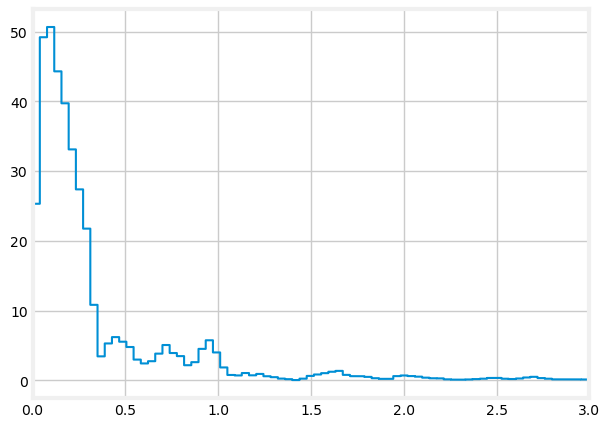

In [ ]:
ffs, pxx, _ = robust_periodogram(data_eda, col_name='de-trend-season')
plt.step(ffs*52, pxx)
# plt.step(ffs*52, ma_pp)
# plt.vlines(tmp_freqs*52, ymin=-10, ymax=200, colors='grey', ls=':')
plt.xlim(0, 3);
# plt.ylim(-1, np.max([pxx, ma_pp])*1.1);

# del ffs, pxx

In [ ]:
(52.17714285714286/48)*7

7.609166666666667

In [ ]:
(8*52.17714285714286)/48

8.696190476190477

In [ ]:
365.24/7

52.17714285714286

In [ ]:
[(1/freq_arr[i]) for i in range(2,7)]

[np.float64(12.91346153846154),
 np.float64(8.60897435897436),
 np.float64(6.45673076923077),
 np.float64(5.165384615384616),
 np.float64(4.30448717948718)]

In [ ]:
1./freq_arr[np.argmax(pxx_arr)+3]

np.float64(4.30448717948718)

In [ ]:
[(1/freq_arr[i]) for i in range(2,15)]

[np.float64(12.91346153846154),
 np.float64(8.60897435897436),
 np.float64(6.45673076923077),
 np.float64(5.165384615384616),
 np.float64(4.30448717948718),
 np.float64(3.6895604395604398),
 np.float64(3.228365384615385),
 np.float64(2.8696581196581197),
 np.float64(2.582692307692308),
 np.float64(2.347902097902098),
 np.float64(2.15224358974359),
 np.float64(1.9866863905325445),
 np.float64(1.8447802197802199)]

In [ ]:
1/8.60897435897436

0.1161578555472822

In [ ]:
1/2.1522

0.46464083263637207

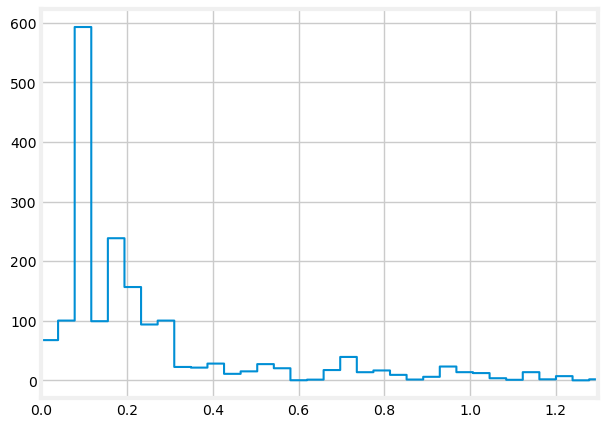

### 3.6 Partial autocorrelation and lag plots

Let us now look at the partial autocorrelation (i.e., correlation with lag $k$ having accounted for correlations with all other lags):

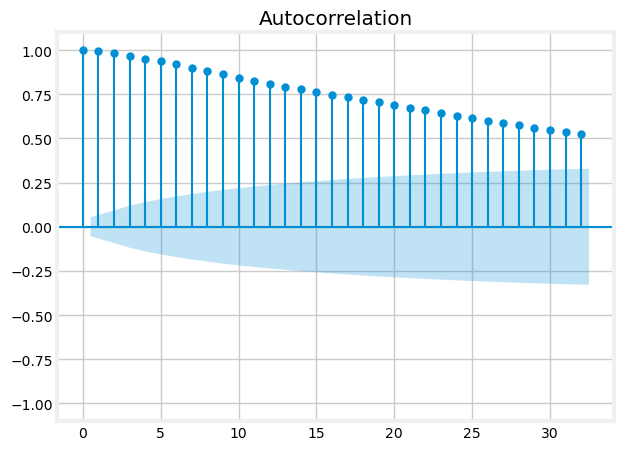

In [ ]:
plot_acf(data_eda['dsci']);
plt.ylim(-1.1, 1.1);

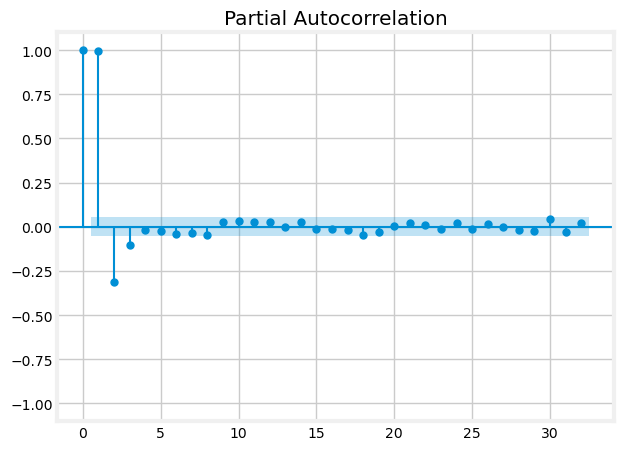

In [ ]:
plot_pacf(data_eda['dsci']);
plt.ylim(-1.1, 1.1);

Clearly, lags 1, 2, and 3 are correlated and anticorrelated with the time series, which suggests the kind of lags that we may want to use in a AR model.

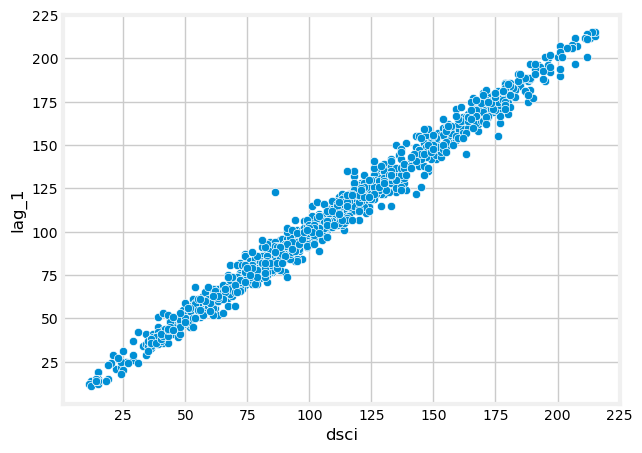

In [ ]:
lag = 'lag_1'

sns.scatterplot(data=data_eda, x='dsci', y=lag)

del lag